<a href="https://colab.research.google.com/github/asegura4488/MecanicaClasica/blob/main/RestriccionParabola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¿Convergió? True
Mensaje: The solution converged.

q1 = -1.661446
q2 = 0.695872

Masa 1: x1 = -1.661446, y1 = 1.380201
Masa 2: x2 = 0.695872, y2 = 0.242119

Longitud de arco S(q2)-S(q1) = 3.000000


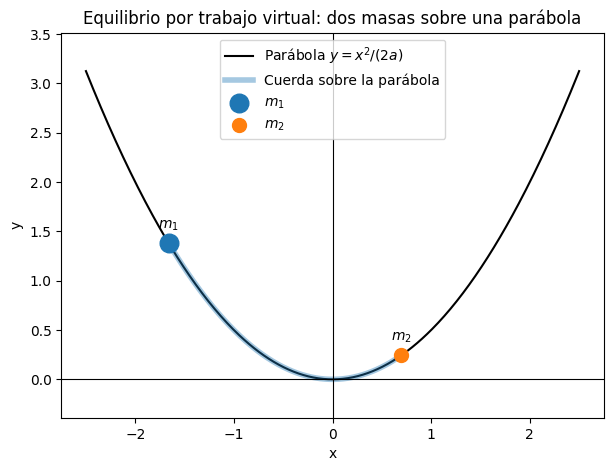

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

# ==========================================
# Parámetros del problema
# ==========================================

a = 1.0          # Parámetro de la parábola: y = x^2/(2a)
m1 = 2.0         # Masa 1
m2 = 3.0         # Masa 2
ell = 3        # Longitud de la cuerda medida sobre la parábola
g = 9.81

# ==========================================
# Longitud de arco
# ==========================================
# Para la parábola:
#
# y = x^2/(2a)
#
# dy/dx = x/a
#
# ds = sqrt(1 + (x/a)^2) dx
#
# Entonces:
#
# S(q) = integral desde 0 hasta q de sqrt(1 + (x/a)^2) dx

def S(q):
    return 0.5 * (
        q * np.sqrt(1 + (q/a)**2)
        + a * np.arcsinh(q/a)
    )

# ==========================================
# Sistema de ecuaciones
# ==========================================
#
# Ecuación 1: ligadura de cuerda
#
# S(q2) - S(q1) = ell
#
# Ecuación 2: equilibrio por trabajo virtual
#
# m1*q1/sqrt(1+q1^2/a^2)
# +
# m2*q2/sqrt(1+q2^2/a^2)
# =
# 0

def equations(vars):
    q1, q2 = vars

    eq1 = S(q2) - S(q1) - ell

    eq2 = (
        m1 * q1 / np.sqrt(1 + (q1/a)**2)
        +
        m2 * q2 / np.sqrt(1 + (q2/a)**2)
    )

    return [eq1, eq2]

# ==========================================
# Solución numérica
# ==========================================

guess = [-0.7, 1.2]

sol = root(equations, guess)

q1, q2 = sol.x

# ==========================================
# Coordenadas cartesianas
# ==========================================

x1 = q1
y1 = q1**2 / (2*a)

x2 = q2
y2 = q2**2 / (2*a)

print("¿Convergió?", sol.success)
print("Mensaje:", sol.message)
print()
print(f"q1 = {q1:.6f}")
print(f"q2 = {q2:.6f}")
print()
print(f"Masa 1: x1 = {x1:.6f}, y1 = {y1:.6f}")
print(f"Masa 2: x2 = {x2:.6f}, y2 = {y2:.6f}")
print()
print(f"Longitud de arco S(q2)-S(q1) = {S(q2)-S(q1):.6f}")

# ==========================================
# Gráfica
# ==========================================

x = np.linspace(-2.5, 2.5, 400)
y = x**2 / (2*a)

x_arc = np.linspace(q1, q2, 300)
y_arc = x_arc**2 / (2*a)

plt.figure(figsize=(7, 5))

plt.plot(x, y, color='k' ,label=r"Parábola $y=x^2/(2a)$")
plt.plot(
    x_arc,
    y_arc,
    linewidth=4,
    alpha=0.4,
    label="Cuerda sobre la parábola"
)

plt.scatter([x1], [y1], s=180, zorder=6, label=r"$m_1$")
plt.scatter([x2], [y2], s=100, zorder=6, label=r"$m_2$")

plt.text(x1, y1 + 0.15, rf"$m_1$", ha="center")
plt.text(x2, y2 + 0.15, rf"$m_2$", ha="center")

plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Equilibrio por trabajo virtual: dos masas sobre una parábola")

plt.axis("equal")
#plt.grid(True)
plt.legend()